In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# output directory for plots
os.makedirs('../plots', exist_ok=True)
output_dir = '../plots/'

# Read results
df = pd.read_csv('../data/runs.csv')

df

,N,threads,trial,seconds,std_seconds,validate
0,100,1,1,0.000608,NaN,OK
1,100,1,2,0.000772,NaN,OK
2,100,1,3,0.001044,NaN,OK
3,100,1,4,0.000626,NaN,OK
4,100,1,5,0.000627,NaN,OK
...,...,...,...,...,...,...
1095,1000,10,7,0.026299,NaN,OK
1096,1000,10,8,0.026396,NaN,OK
1097,1000,10,9,0.026239,NaN,OK
1098,1000,10,10,0.026371,NaN,OK


In [28]:
# Use only 'Average' rows
avg_df = df[df['trial'] == 'Average'].copy()

# Ensure numeric types
for col in ['N', 'threads', 'seconds']:
    avg_df[col] = pd.to_numeric(avg_df[col], errors='coerce')
avg_df = avg_df.dropna(subset=['N', 'threads', 'seconds'])

# Baseline T1 per N: prefer p==1, else fallback to smallest available p
t1_map = (
    avg_df[avg_df['threads'] == 1]
    .set_index('N')['seconds']
)
if t1_map.index.nunique() < avg_df['N'].nunique():
    # Fallback: smallest p per N
    fallback = (
        avg_df.sort_values('p')
        .groupby('N', as_index=True)['seconds']
        .first()
    )
    t1_map = t1_map.combine_first(fallback)

# Attach T1 per N
avg_df = avg_df.merge(t1_map.rename('T1'), on='N', how='left')

# Metrics per (N, p)
avg_df['Speedup'] = avg_df['T1'] / avg_df['seconds']
avg_df['Efficiency'] = avg_df['Speedup'] / avg_df['threads']
avg_df['Karp_Flatt'] = np.where(
    avg_df['threads'] > 1,
    ((1 / avg_df['Speedup']) - (1 / avg_df['threads'])) / (1 - (1 / avg_df['threads'])),
    np.nan
)

# Clean infinities
avg_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Optional: save computed metrics
# avg_df.to_csv('../plots/metrics_perN.csv', index=False)

avg_2D_df = avg_df[avg_df['N'] == 1000]

avg_df

,N,threads,trial,seconds,std_seconds,validate,T1,Speedup,Efficiency,Karp_Flatt
0,100,1,Average,0.000713,0.000145,OK,0.000713,1.000000,1.000000,NaN
1,100,2,Average,0.000416,0.000093,OK,0.000713,1.713942,0.856971,0.166900
2,100,3,Average,0.000296,0.000051,OK,0.000713,2.408784,0.802928,0.122721
3,100,4,Average,0.000288,0.000043,OK,0.000713,2.475694,0.618924,0.205236
4,100,5,Average,0.000272,0.000017,OK,0.000713,2.621324,0.524265,0.226858
...,...,...,...,...,...,...,...,...,...,...
95,1000,6,Average,0.030603,0.000280,OK,0.126667,4.139039,0.689840,0.089922
96,1000,7,Average,0.028740,0.000668,OK,0.126667,4.407342,0.629620,0.098043
97,1000,8,Average,0.026593,0.000139,OK,0.126667,4.763171,0.595396,0.097079
98,1000,9,Average,0.027607,0.001448,OK,0.126667,4.588220,0.509802,0.120193


Plots saved in 'plots/' directory.


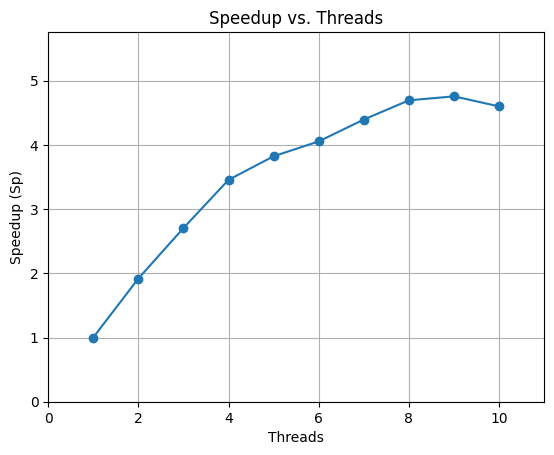

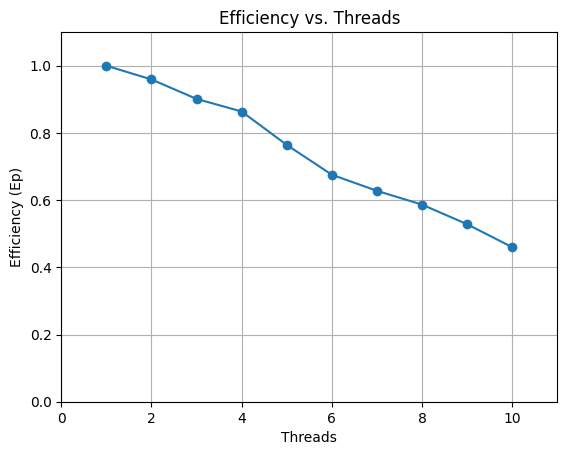

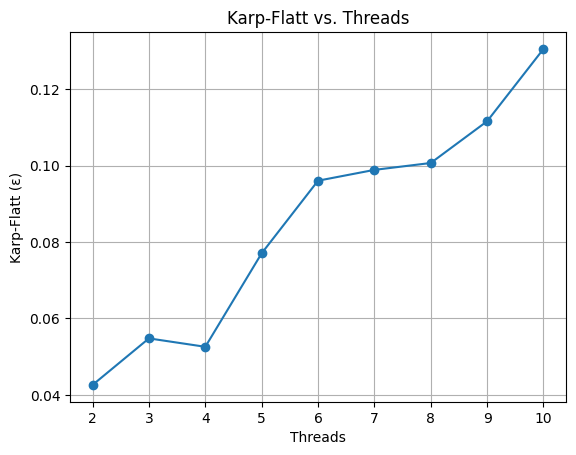

In [22]:
# Speedup plot
plt.figure()
plt.plot(avg_2D_df['threads'].to_numpy(), avg_2D_df['Speedup'].to_numpy(), marker='o')
plt.xlabel('Threads')
plt.ylabel('Speedup (Sp)')
plt.title('Speedup vs. Threads')
plt.grid(True)
plt.xlim(0, max(avg_2D_df['threads']) + 1)
plt.ylim(0, max(avg_2D_df['Speedup']) + 1)
plt.savefig(f'{output_dir}speedup.png')

# Efficiency plot
plt.figure()
plt.plot(avg_2D_df['threads'].to_numpy(), avg_2D_df['Efficiency'].to_numpy(), marker='o')
plt.xlabel('Threads')
plt.ylabel('Efficiency (Ep)')
plt.title('Efficiency vs. Threads')
plt.grid(True)
plt.xlim(0, max(avg_2D_df['threads']) + 1)
plt.ylim(0, max(avg_2D_df['Efficiency']) + 0.1)
plt.savefig(f'{output_dir}efficiency.png')

# Karp-Flatt plot
plt.figure()
plt.plot(avg_2D_df['threads'].to_numpy(), avg_2D_df['Karp_Flatt'].to_numpy(), marker='o')
plt.xlabel('Threads')
plt.ylabel('Karp-Flatt (ε)')
plt.title('Karp-Flatt vs. Threads')
plt.grid(True)
# plt.xlim(0, max(avg_2D_df['threads']) + 1)
# plt.ylim(0, max(avg_2D_df['Karp_Flatt']) + 0.05)
plt.savefig(f'{output_dir}karp_flatt.png')

print("Plots saved in 'plots/' directory.")


3D plots saved in 'plots/' directory.


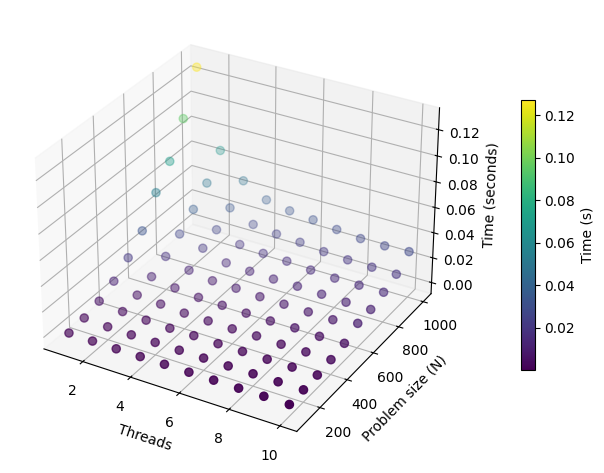

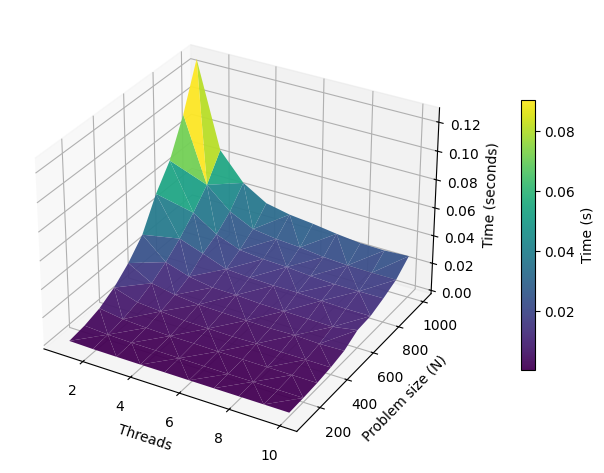

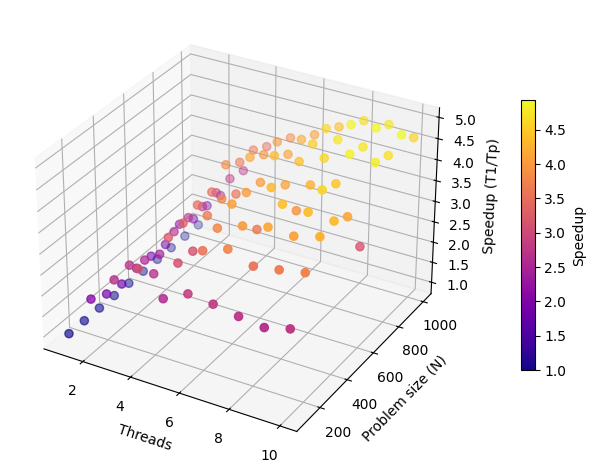

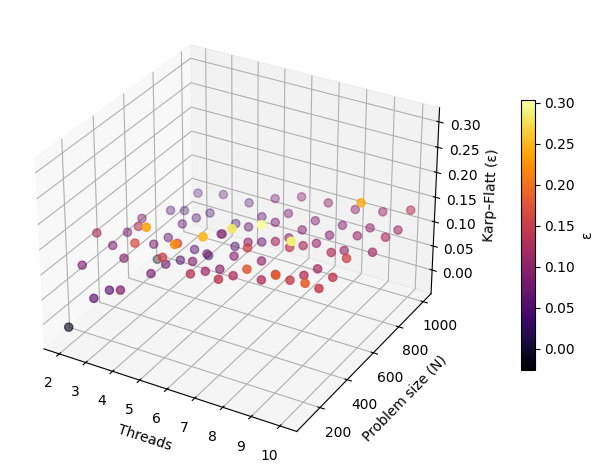

In [23]:
# 3D plots with N as third axis
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm
from matplotlib.tri import Triangulation

# Use only 'Average' rows
avg_df = df[df['trial'] == 'Average'].copy()

# Ensure numeric
for col in ['N', 'threads', 'seconds']:
    avg_df[col] = pd.to_numeric(avg_df[col], errors='coerce')
avg_df = avg_df.dropna(subset=['N', 'threads', 'seconds'])

# 3D scatter: time vs p and N
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x = avg_df['threads'].to_numpy()
y = avg_df['N'].to_numpy()
z = avg_df['seconds'].to_numpy()
sc = ax.scatter(x, y, z, c=z, cmap=cm.viridis, s=35)
ax.set_xlabel('Threads')
ax.set_ylabel('Problem size (N)')
ax.set_zlabel('Time (seconds)')
fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1, label='Time (s)')
plt.tight_layout()
plt.savefig(f'{output_dir}time_3d_scatter.png', dpi=150, bbox_inches='tight')

# Optional surface (works best with dense grid)
try:
    tri = Triangulation(x, y)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_trisurf(tri, z, cmap=cm.viridis, linewidth=0.2, antialiased=True, alpha=0.95)
    ax.set_xlabel('Threads')
    ax.set_ylabel('Problem size (N)')
    ax.set_zlabel('Time (seconds)')
    fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label='Time (s)')
    plt.tight_layout()
    plt.savefig(f'{output_dir}time_3d_surface.png', dpi=150, bbox_inches='tight')
except Exception as e:
    print(f"Surface plot skipped: {e}")

# Compute speedup per N using p==1 as baseline (fallback to smallest p if p==1 missing)
t1_map = (
    avg_df[avg_df['threads'] == 1].set_index('N')['seconds']
    .reindex(avg_df['N'].unique())
)
if t1_map.isna().any():
    fallback = avg_df.sort_values('threads').groupby('N')['seconds'].first()
    t1_map = t1_map.fillna(fallback)

avg_df = avg_df.merge(t1_map.rename('T1'), on='N', how='left')
avg_df['Speedup'] = avg_df['T1'] / avg_df['seconds']
avg_df = avg_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Speedup'])
# NEW: ensure Efficiency exists for later trisurf cell
avg_df['Efficiency'] = avg_df['Speedup'] / avg_df['threads']

# 3D scatter: speedup vs p and N
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x = avg_df['threads'].to_numpy()
y = avg_df['N'].to_numpy()
z = avg_df['Speedup'].to_numpy()
sc = ax.scatter(x, y, z, c=z, cmap=cm.plasma, s=35)
ax.set_xlabel('Threads')
ax.set_ylabel('Problem size (N)')
ax.set_zlabel('Speedup (T1/Tp)')
fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1, label='Speedup')
plt.tight_layout()
plt.savefig(f'{output_dir}speedup_3d_scatter.png', dpi=150, bbox_inches='tight')

# 3D scatter: Karp–Flatt vs threads and N (exclude threads=1)
kf_df = avg_df[avg_df['threads'] > 1].copy()
kf_df['Karp_Flatt'] = ((1 / kf_df['Speedup']) - (1 / kf_df['threads'])) / (1 - (1 / kf_df['threads']))
kf_df = kf_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Karp_Flatt'])

if len(kf_df) > 0:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    x = kf_df['threads'].to_numpy()
    y = kf_df['N'].to_numpy()
    z = kf_df['Karp_Flatt'].to_numpy()
    sc = ax.scatter(x, y, z, c=z, cmap=cm.inferno, s=35)
    ax.set_xlabel('Threads')
    ax.set_ylabel('Problem size (N)')
    ax.set_zlabel('Karp–Flatt (ε)')
    fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1, label='ε')
    plt.tight_layout()
    plt.savefig(f'{output_dir}karp_flatt_3d_scatter.png', dpi=150, bbox_inches='tight')
else:
    print("No valid Karp–Flatt data for p > 1")

print("3D plots saved in 'plots/' directory.")

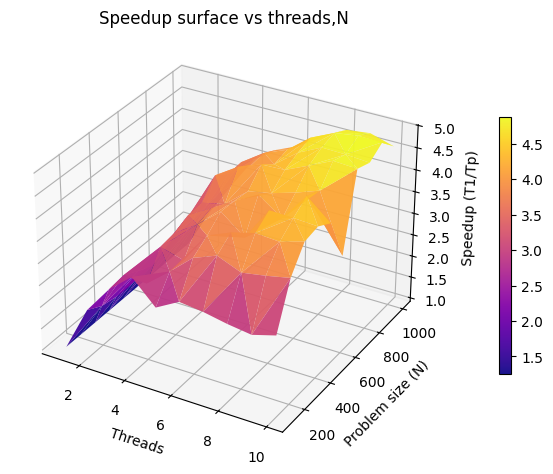

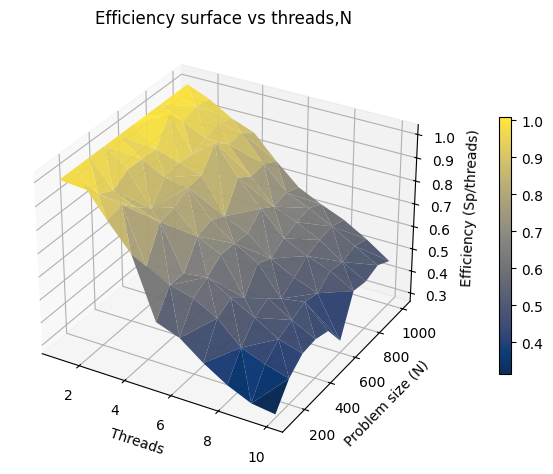

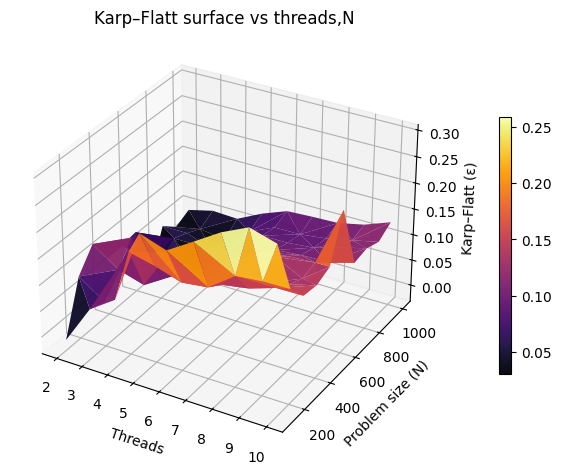

3D triangular surfaces saved to 'plots/' directory.


In [24]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.tri import Triangulation
from matplotlib import cm

# Ensure derived metrics exist (in case previous cells redefined avg_df)
if 'Efficiency' not in avg_df.columns and 'Speedup' in avg_df.columns:
    avg_df['Efficiency'] = avg_df['Speedup'] / avg_df['threads']
if 'Karp_Flatt' not in avg_df.columns and 'Speedup' in avg_df.columns:
    mask = avg_df['threads'] > 1
    avg_df.loc[mask, 'Karp_Flatt'] = ((1 / avg_df.loc[mask, 'Speedup']) - (1 / avg_df.loc[mask, 'threads'])) / (1 - (1 / avg_df.loc[mask, 'threads']))

def trisurf_plot(x, y, z, xlabel, ylabel, zlabel, title, outfile, cmap=cm.viridis):
    # Keep only finite points
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x, y, z = x[mask], y[mask], z[mask]
    if x.size < 3:
        print(f"Not enough points for surface: {title}")
        return
    tri = Triangulation(x, y)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_trisurf(tri, z, cmap=cmap, linewidth=0.2, antialiased=True, alpha=0.95)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_zlabel(zlabel)
    ax.set_title(title)
    fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1)
    plt.tight_layout()
    plt.savefig(f"{output_dir}{outfile}", dpi=150, bbox_inches="tight")
    plt.show()  # show inline
    # plt.close(fig)  # optional: close after showing if many figs

# Speedup surface: z = Speedup(threads, N)
trisurf_plot(
    avg_df['threads'].to_numpy(),
    avg_df['N'].to_numpy(),
    avg_df['Speedup'].to_numpy(),
    'Threads', 'Problem size (N)', 'Speedup (T1/Tp)',
    'Speedup surface vs threads,N', 'speedup_3d_surface.png', cmap=cm.plasma
)

# Efficiency surface: z = Efficiency(threads, N)
trisurf_plot(
    avg_df['threads'].to_numpy(),
    avg_df['N'].to_numpy(),
    avg_df['Efficiency'].to_numpy(),
    'Threads', 'Problem size (N)', 'Efficiency (Sp/threads)',
    'Efficiency surface vs threads,N', 'efficiency_3d_surface.png', cmap=cm.cividis
)

# Karp–Flatt surface: exclude p == 1 (undefined)
mask = avg_df['threads'] > 1
trisurf_plot(
    avg_df.loc[mask, 'threads'].to_numpy(),
    avg_df.loc[mask, 'N'].to_numpy(),
    avg_df.loc[mask, 'Karp_Flatt'].to_numpy(),
    'Threads', 'Problem size (N)', 'Karp–Flatt (ε)',
    'Karp–Flatt surface vs threads,N', 'karp_flatt_3d_surface.png', cmap=cm.inferno
)

print("3D triangular surfaces saved to 'plots/' directory.")